In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
x_train.shape

(800,)

In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [33]:
model = keras.Sequential([
    layers.Input(shape=(2,)),                 # 2 input features (x, y coords)
    layers.Dense(16, activation="relu"),       # hidden layer 1: 16 neurons
    layers.Dense(8, activation="relu"),        # hidden layer 2: 8 neurons
    layers.Dense(1, activation="sigmoid"),     # output layer: 1 neuron (binary prob)
])

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",   # standard loss for binary classification
    metrics=["accuracy"],
)

In [27]:
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0,
)
 

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")


Test accuracy: 0.9700
Test loss:     0.0457


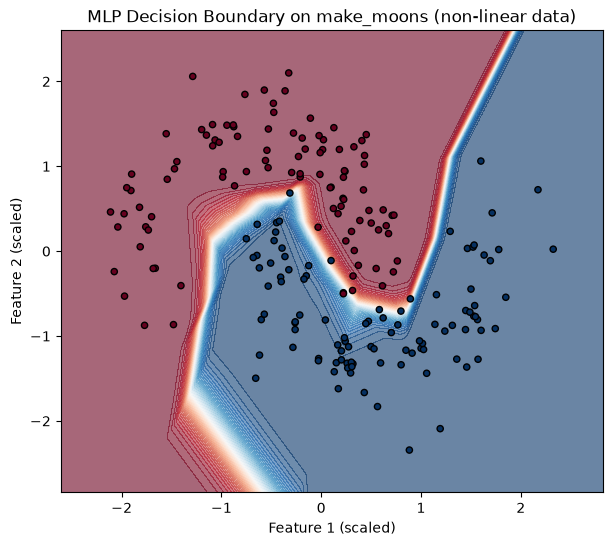

In [31]:
def plot_decision_boundary(model, X, y, filename):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0).reshape(xx.shape)
 
    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, preds, levels=50, cmap="RdBu", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=20)
    plt.title("MLP Decision Boundary on make_moons (non-linear data)")
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    # plt.savefig(filename, dpi=120, bbox_inches="tight")
    # print(f"Saved decision boundary plot to {filename}")
 
plot_decision_boundary(model, x_test, y_test, "decision_boundary.png")

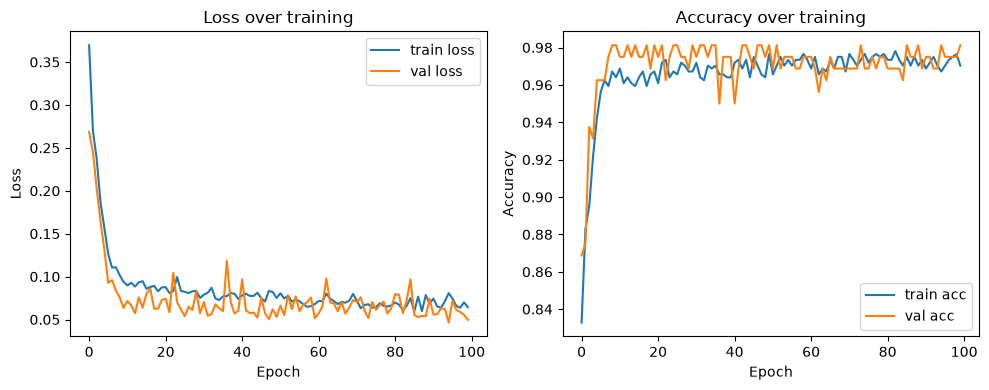

In [32]:
plt.figure(figsize=(10, 4))
 
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over training")
plt.legend()
 
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over training")
plt.legend()
 
plt.tight_layout()

 